<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EA%B0%9C%EB%A1%A0_16%EC%B0%A8%EC%8B%9C_03_CNN_%EB%AA%A8%EB%8D%B8_%EB%B9%8C%EB%93%9C_%EC%8B%A4%EC%8A%B5_SVHN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 학습 목표
- CNN 구조 설계부터 실험까지 end-to-end 경험
- Feature Extractor와 Classifier 분리 설계
- Conv/Pool/ReLU 조합과 파라미터 계산
- Hook을 활용한 레이어 출력 shape 추적
- 하이퍼파라미터 튜닝 경험


## 데이터셋: SVHN (Street View House Numbers)
- Google Street View에서 수집한 집 번호 이미지
- 10개 클래스 (숫자 0-9)
- 32×32 컬러 이미지
- 학습: 73,257개, 테스트: 26,032개

In [1]:
!sudo apt-get install locales -qq


# 2. 한국어 (ko_KR.UTF-8) locale 생성
# 이 단계에서 오류가 나지 않아야 해요!
!sudo locale-gen ko_KR.UTF-8


# 3. 환경 변수 설정
# 파이썬 코드 안에서 실행합니다.
import os
os.environ['LANG'] = 'ko_KR.UTF-8'
os.environ['LC_ALL'] = 'ko_KR.UTF-8'
os.environ['LC_CTYPE'] = 'ko_KR.UTF-8'
os.environ['LANGUAGE'] = 'ko_KR.UTF-8'

Generating locales (this might take a while)...
  ko_KR.UTF-8... done
Generation complete.


런타임 다시 시작

In [1]:
# 나눔 폰트 설치 (Colab에서 한글 표시를 위해 가장 많이 사용돼요)
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
!sudo fc-cache -fv > /dev/null 2>&1


# Matplotlib 등에서 한글 폰트 설정을 위한 코드 (streamlit과는 직접 관련 없을 수도 있지만,
# 만약을 위해 환경 준비 차원에서 실행해주세요)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os


# 설치된 폰트 경로 확인
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 예시
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    print("한글 폰트 설정 완료: NanumBarunGothic")
else:
    print(f"Warning: 폰트 파일이 없습니다: {font_path}")


# (선택 사항) 시스템에 설치된 폰트 목록 확인
# [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

한글 폰트 설정 완료: NanumBarunGothic


In [2]:
# PyTorch 및 관련 라이브러리 임포트
import torch  # PyTorch 메인 라이브러리
import torch.nn as nn  # 신경망 모듈 (레이어, 손실함수 등)
import torch.optim as optim  # 최적화 알고리즘 (Adam, SGD 등)
import torch.nn.functional as F  # 활성화 함수, Softmax 등
from torch.utils.data import DataLoader  # 데이터 로더 (배치 처리)


# torchvision: 컴퓨터 비전 관련 유틸리티
import torchvision  # 비전 관련 전체 모듈
import torchvision.transforms as transforms  # 이미지 전처리 및 증강
from torchvision import datasets  # SVHN, CIFAR 등 표준 데이터셋


# 데이터 처리 및 시각화
import numpy as np  # 수치 연산 라이브러리
import matplotlib.pyplot as plt  # 그래프 및 이미지 시각화
from collections import OrderedDict  # 순서가 보장되는 딕셔너리


# 진행 상황 표시 (선택사항)
from tqdm import tqdm  # 진행률 표시줄 (progress bar)


# GPU 사용 가능 여부 확인 및 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# torch.cuda.is_available(): CUDA(GPU)가 사용 가능한지 확인
# GPU 있으면 'cuda', 없으면 'cpu' 사용
print(f'사용 디바이스: {device}')


# 재현성을 위한 시드 고정
torch.manual_seed(42)  # PyTorch 난수 시드 고정
np.random.seed(42)  # NumPy 난수 시드 고정
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)  # CUDA 난수 시드 고정
    torch.backends.cudnn.deterministic = True  # 결정적 알고리즘 사용
    torch.backends.cudnn.benchmark = False  # 벤치마크 비활성화 (재현성 우선)


print('환경 설정 완료!')
print(f'PyTorch 버전: {torch.__version__}')
print(f'Torchvision 버전: {torchvision.__version__}')

사용 디바이스: cuda
환경 설정 완료!
PyTorch 버전: 2.10.0+cu128
Torchvision 버전: 0.25.0+cu128


In [52]:
transforms_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),
    # 이미지32*32 크기로 무작위로 자르되, 4픽셀 패딩 추가
    # 패딩 때문에 36*36, 여기서 32*32를 랜덤한 위치에서 자름(위치 변화)
    transforms.RandomHorizontalFlip(p=0.5),
    # 50% 확률로 이미지를 좌우 반전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # 밝기, 대비, 채도 무작위로 변경 (조명, 조건 변화 시뮬레이션)
    # +- 20% 변경
    # hue : 색상(빨강, 파랑 >> 색의 고유한 특성)

    transforms.ToTensor(),
    # PIL image >> Pytorch Tensor로 변경 (HWC >> CHW) 변경
    # 픽셀 [0,255] >> [0.0, 1.0] 정규화
    transforms.Normalize(mean = (0.5,0.5,0.5),std = (0.5,0.5,0.5))
    # 각 채널 평균 0.5, 표준편차 0.5 범위 변경
    # Normalize = (pixel - mean) / std
    # [0, 1] >> [-1, 1]
])

transforms_test = transforms.Compose([

    transforms.ToTensor(),
    # PIL image >> Pytorch Tensor로 변경 (HWC >> CHW) 변경
    # 픽셀 [0,255] >> [0.0, 1.0] 정규화
    transforms.Normalize(mean = (0.5,0.5,0.5),std = (0.5,0.5,0.5))
    # 각 채널 평균 0.5, 표준편차 0.5 범위 변경
    # Normalize = (pixel - mean) / std
    # [0, 1] >> [-1, 1]
])

In [53]:
from re import split
from logging import root

train_dataset = datasets.SVHN(
    root = './data',
    split = 'train',
    download = True,
    transform = transforms_train
)

test_dataset = datasets.SVHN(
    root = './data',
    split = 'test',
    download = True,
    transform = transforms_test
)

In [54]:
# 데이터 로더 생성

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = False,
    num_workers = 2,
    pin_memory=True
)

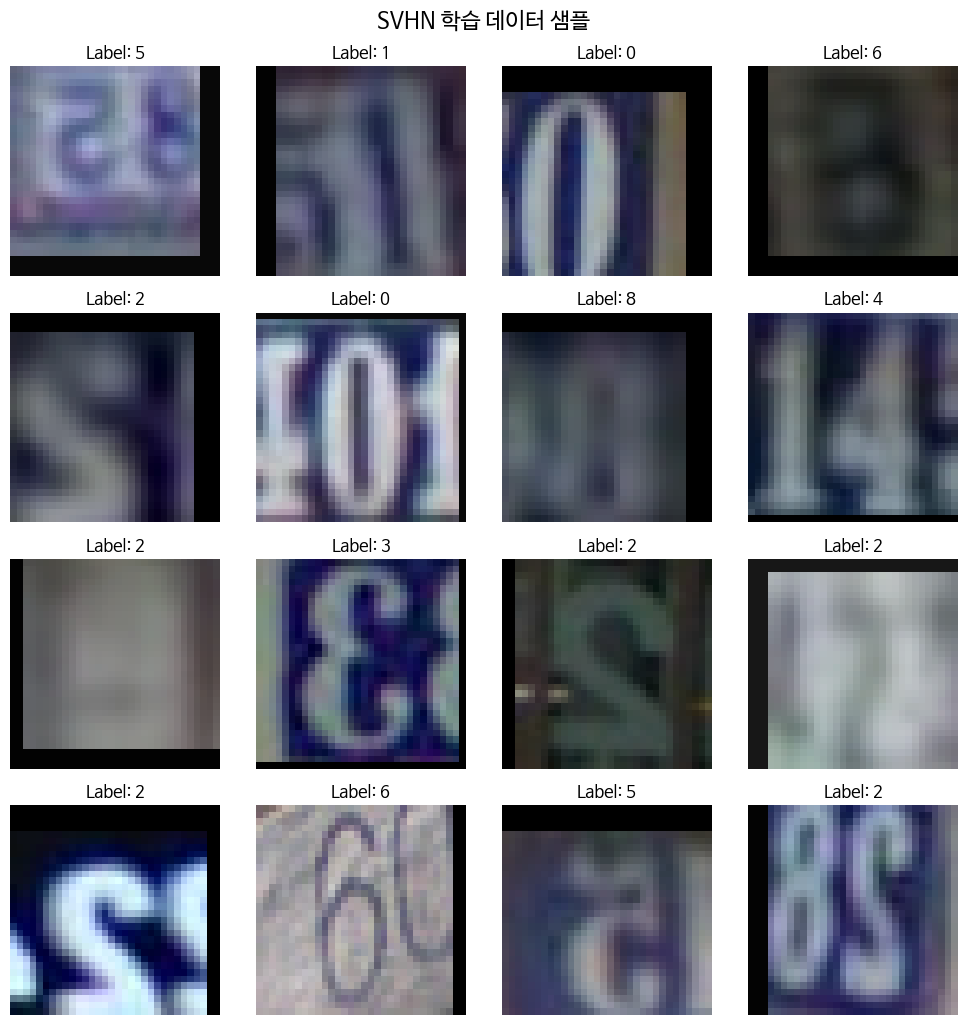

In [55]:
# 샘플 이미지 시각화
# 왜 해요? 데이터 셋이 제대로 로드되었는지 확인할려고 한다.


class_names = ['0','1','2','3','4','5','6','7','8','9']


images, labels = next(iter(train_loader))


def denormalize(tensor):
    return tensor * 0.5 + 0.5
    # 정규화 역변환: pixel = (normlized * std) + mean


# 16개 이미지를 4x4 그리드로 시각화
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)  # 4x4 그리드의 i+1번째 위치


    # 이미지를 (C, H, W) -> (H, W, C) 형태로 변환
    img = denormalize(images[i]).cpu().numpy().transpose(1, 2, 0)


    # 이미지 표시
    plt.imshow(img)
    plt.title(f'Label: {class_names[labels[i]]}')  # 레이블 표시
    plt.axis('off')  # 축 숨기기


plt.tight_layout()  # 레이아웃 자동 조정
plt.suptitle('SVHN 학습 데이터 샘플', y=1.02, fontsize=16)
plt.show()

CNN 모델 정의

In [56]:
class SVHN_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # feature extraction (특징 추출)
        # Conv2d block 1 : input_channel (3) rgb >> 32 out_channel (채널 필터 개수)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,
                               kernel_size=3, stride=1, padding=1)
        # 파라미터 수 : (3*3*3+1)*32 = 896
        # 출력 크기 : [batch_size, c, h, w] = [batch_size, 32, 32, 32]

        self. pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Maxpooling : 공간 해상도 절반 축소
        # 2*2 영역에서 최대값(max) 추출(가로, 세로 반으로 줄어듬) >> 2칸씩 이동
        # 출력 크기 [batch_size, 32, 16, 16]

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,
                               kernel_size=3, stride=1, padding=1)
        # 파라미터 수 : (3*3*32+1)*64 = 8496
        # 출력 크기 [batch_size, 64, 16, 16]

        self. pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Maxpooling : 공간 해상도 절반 축소
        # 2*2 영역에서 최대값(max) 추출(가로, 세로 반으로 줄어듬) >> 2칸씩 이동
        # 출력 크기 [batch_size, 64, 8, 8]

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128,
                               kernel_size=3, stride=1, padding=1)
        # 파라미터 수 : (3*3*64+1)*128 = 73856
        # 출력 크기 [batch_size, 128, 8, 8]

        self. pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Maxpooling : 공간 해상도 절반 축소
        # 2*2 영역에서 최대값(max) 추출(가로, 세로 반으로 줄어듬) >> 2칸씩 이동
        # 출력 크기 [batch_size, 128, 4, 4]

        # classifier (분류기)
        # fc (fully connected 완전 연결층)
        # 추출된 특징 (2차원) >> 최종 분류(1차원)
        self.fc1 = nn.Linear(in_features=128*4*4, out_features=512)
        # 파라미터 수 : (128*4*4+1)*512 = 100490886

        # Dropout : 과적합 방지 (학습시 50% 랜덤하게 비활성화)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=512, out_features=num_classes)
        # 파리미터 수 : (512+1)*10(num_classes) = 5130

    def forward(self,x):
        # features extraction
        # Conv block 1
        x = self.conv1(x)   # [batch_size,3,32,32] >> [batch_size,32,32,32]
        x = F.relu(x)
        x = self.pool1(x)   # [batch_size,32,32,32] >> [batch_size,32,16,16]

        # Conv block 2
        x = self.conv2(x)   # [batch_size,32,16,16] >> [batch_size,64,16,16]
        x = F.relu(x)
        x = self.pool2(x)   # [batch_size,64,16,16] >> [batch_size,64,8,8]

        # Conv block 3
        x = self.conv3(x)   # [batch_size,64,8,8] >> [batch_size,128,8,8]
        x = F.relu(x)
        x = self.pool3(x)   # [batch_size,128,8,8] >> [batch_size,128,4,4]

        # classifier (분류기)
        # flatten (1차원으로 펼쳐줌)
        x = x.view(x.size(0),-1)    # [batch_size,128,4,4] >> [batch_size,128*4*4]
        # x.size(0) batch_size, -1 나머지 차원을 자동 계산해줘

        # fc 1
        x = self.fc1(x)         # [batch_size,2048] >> [batch_size,512]
        x = F.relu(x)
        x = self.dropout(x)     # dropout 학습 시에만 적용

        # fc 2(출력층)
        x = self.fc2(x) # [batch_size,512] >> [batch_size,10]

        return x

In [57]:
model = SVHN_CNN(num_classes=10)
model =  model.to(device)

In [58]:
print(model)

SVHN_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [59]:
model.conv1

Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [60]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p .requires_grad)
    return total

total_params = count_parameters(model)
print(f'모델 총 파라미터 수:{total_params:,}개')

모델 총 파라미터 수:1,147,466개


Hook 사용한 레이어 출력 shape 추적

In [62]:
# hook: 모델의 중간 레이어 출력을 가로채는 매커니즘

# layer 별 출력 저장
layer_outputs = OrderedDict()

def register_hooks(model):
    handles = []

    def hook_fn(module, input, output):
        # module : 현재 실행 중인 레이어 객체, input: layer 입력, output layer 출력
        layer_name = module.__class__.__name__
        # 클래스 이름 사용, 레이어 이름 추출
        # 예) Con2d, ReLU

        # 동일한 layer type 이 여러 개 있으면, 번호 추가
        # 중복된 이름 처리 예) Conv2d 이미 2개 있다면 >> count=2
        count = sum(1 for k in layer_outputs.keys() if layer_name in k)
        if count > 0:
            layer_name = f'{layer_name}_{count+1}'
            # 예) Conv2d_3

        layer_outputs[layer_name] = output.shape
        # 출력 크기 >> 딕셔너리에 저장
    # 중복이름 처리 1번째 만나는 Conv2d >> Conv2d, 2번째 만나면 Conv2d_2 ....

    # 모든 하위 모듈(모든 레이어)에 hook 등록
    for name, module in model.named_modules():
        #전체 모델 자체는 제외(하위 레이어만 등록)
        if len(list(module.children())) == 0 and module != model:
            # len(list(module.children())) == 0 자식이 없는 레이어
            # Conv2d, MaxPool2d >> 개별로 등록

            handle = module.register_forward_hook(hook_fn)
            # register_forward_hook: 데이터가 레이어 통과 시 hook_fn 실행해라

            handles.append(handle)

    return handles

# hook 등록
hook_handles = register_hooks(model)
# print(hook_handles)
print(len(hook_handles)) # 9
# 9개가 의미하는 것은 특정 9개 지점에 hook 표식 남겼다.

# 더미 데이터 입력, 순전파 실행 (hook trigger hook 발생 유도)
# 입력 [batch_size = 1, channel = 3, height = 32, width =32]

dummy_input = torch.randn(1, 3, 32, 32).to(device)

with torch.no_grad():
    output = model(dummy_input)

# print(output)
# 모델 예측값 (logits) 10개 예측값 (cifar10이면 실제 값 10개 클래스)
# tensor([[ 0.0540, -0.0576, -0.1109,  0.0025, -0.0295,  0.0456,  0.1583, -0.1590,
#           0.0287,  0.0090]], device='cuda:0')


for layer_name, shape in layer_outputs.items():
    print(f'{layer_name:<25} {str(tuple(shape)):>30}')


# hook 제거 (메모리 정리)
for handle in hook_handles:
    handle.remove()

9
Conv2d                                   (1, 32, 32, 32)
MaxPool2d                                (1, 32, 16, 16)
Conv2d_2                                 (1, 64, 16, 16)
MaxPool2d_2                                (1, 64, 8, 8)
Conv2d_3                                  (1, 128, 8, 8)
MaxPool2d_3                               (1, 128, 4, 4)
Linear                                          (1, 512)
Dropout                                         (1, 512)
Linear_2                                         (1, 10)


학습 함수 정의

In [80]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0 # epoch(학습) 전체 손실 누적
    correct = 0       # 맞춘 샘플 수
    total = 0          # 전체 샘플 수

    pbar = tqdm(train_loader, desc="학습중이예요", leave=False)
    # leave=False : 학습이 끝나면 진행 바(pbar) 사라지게 함

    for batch_idx, (inputs, labels) in enumerate(pbar):
        inputs = inputs.to(device) # [batch_size, 3, 32, 32]
        labels = labels.to(device) # [batch_size]

        optimizer.zero_grad()
        outputs = model(inputs)    # [batch_size, 10]

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()\

        running_loss += loss.item() * inputs.size(0)
        # loss.item() 스칼라 값(파이선 인식 숫자), inputs.size(0) 현재 배치 크기

        _, predicted = outputs.max(1)
        # max(1) dim=1 클래스 차원에서 최대값 >> index 반환
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        # 진행률 업데이트
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100* correct / total:.2f}%'
        })

    # 에폭 평균 손실 및 정확도 계산
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

평가 함수 정의

In [81]:
def evaluate(model, test_loader, criterion, device):
    model.eval()


    running_loss = 0.0 # epoch(학습) 전체 손실 누적
    correct = 0        # 맞춘 샘플 수
    total = 0          # 전체 샘플 수


    with torch.no_grad():
        pbar = tqdm(test_loader, desc='평가중', leave=False)


        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)


            outputs = model(inputs)


            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)


            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)


            # 진행률 표시줄 업데이트
            pbar.set_postfix({
                'loss' : f'{loss.item():.4f}',
                'acc' : f'{100 * correct / total:.2f}%'
            })


    # 평균 손실 및 정확도 계산
    avg_loss = running_loss / total
    accuracy =100 * correct / total


    return avg_loss, accuracy

학습 설정 및 실행

In [82]:
ciriterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001,
    weight_decay = 1e-4 # L2 정규화
)

num_epochs = 10

# 학습 히스토리 저장
train_losses = []
train_accs = []
test_losses = []
test_accs = []

print(num_epochs)
print(batch_size)
print(optimizer.param_groups[0]['lr'])
print(optimizer.param_groups[0]['weight_decay'])    # 가중치 감쇠
print(optimizer.__class__.__name__)

10
128
0.001
0.0001
Adam


In [83]:
best_acc = 0.0

for epoch in range(num_epochs):
    # 학습 단계
    train_loss, train_acc = \
    train_one_epoch(model, train_loader, ciriterion, optimizer, device)

    # 평가 단계
    test_loss, test_acc = \
    evaluate(model, test_loader, ciriterion, device)

    # 결과 저장
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    # epoch 결과 출력
    print(f'학습 -  loss : {train_loss:.4f}, Accuracy : {train_acc:.2f}%')
    print(f'평가 -  loss : {test_loss:.4f}, Accuracy : {test_acc:.2f}%')

    # 최고 성능 모델 저장
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_svhn_model.pth')
        # state_dict() : 모델의 모든 파라미터를 딕셔너리로 반환
        print(f'와우 당신의 정확도는 {best_acc:.2f}%')

학습 -  loss : 1.8408, Accuracy : 34.71%
평가 -  loss : 1.0868, Accuracy : 64.94%
와우 당신의 정확도는 64.94%


학습 -  loss : 1.1270, Accuracy : 62.00%
평가 -  loss : 0.7704, Accuracy : 74.95%
와우 당신의 정확도는 74.95%


학습 -  loss : 0.8922, Accuracy : 70.78%
평가 -  loss : 0.6720, Accuracy : 78.66%
와우 당신의 정확도는 78.66%


학습 -  loss : 0.7612, Accuracy : 75.52%
평가 -  loss : 0.5584, Accuracy : 82.05%
와우 당신의 정확도는 82.05%


학습 -  loss : 0.6812, Accuracy : 78.54%
평가 -  loss : 0.5123, Accuracy : 83.60%
와우 당신의 정확도는 83.60%


학습 -  loss : 0.6297, Accuracy : 80.17%
평가 -  loss : 0.4757, Accuracy : 85.28%
와우 당신의 정확도는 85.28%


학습 -  loss : 0.5951, Accuracy : 81.32%
평가 -  loss : 0.4491, Accuracy : 86.22%
와우 당신의 정확도는 86.22%


학습 -  loss : 0.5627, Accuracy : 82.48%
평가 -  loss : 0.4376, Accuracy : 86.66%
와우 당신의 정확도는 86.66%


학습 -  loss : 0.5340, Accuracy : 83.56%
평가 -  loss : 0.3915, Accuracy : 88.22%
와우 당신의 정확도는 88.22%


학습 -  loss : 0.5230, Accuracy : 83.84%
평가 -  loss : 0.4028, Accuracy : 87.77%


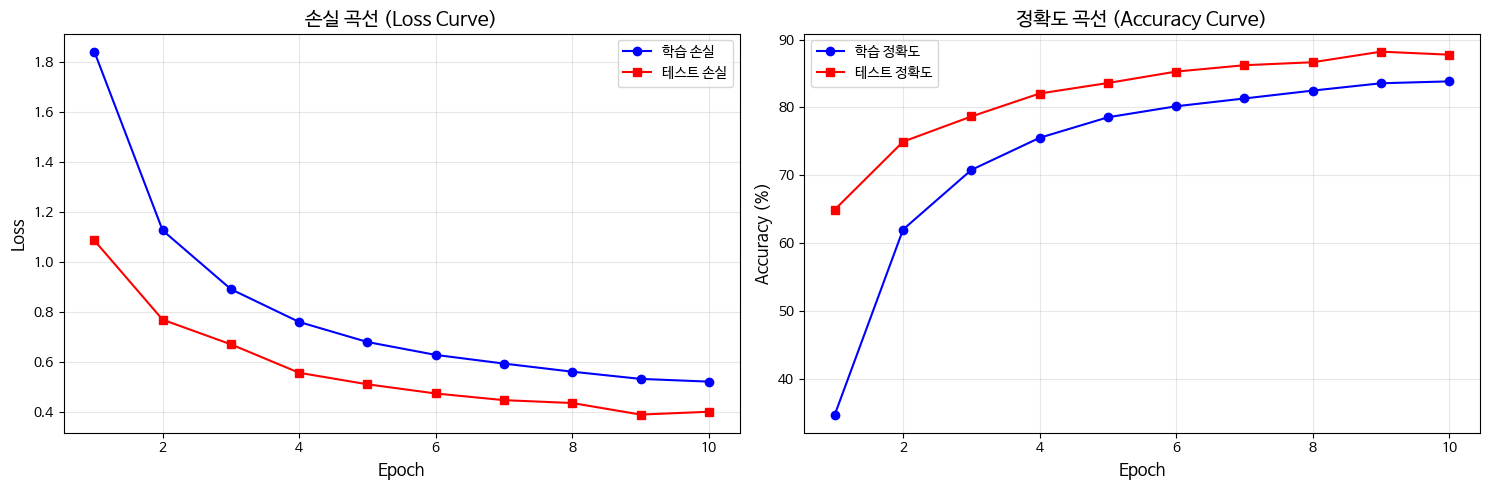


최종 성능 요약:
최종 학습 손실: 0.5230
최종 학습 정확도: 83.84%
최종 테스트 손실: 0.4028
최종 테스트 정확도: 87.77%
최고 테스트 정확도: 88.22%


In [84]:
# 학습 곡선 그리기


# 에폭 번호 (x축)
epochs_range = range(1, num_epochs + 1)


# 2x1 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


# 왼쪽 그래프: 손실 곡선
ax1.plot(epochs_range, train_losses, 'b-', label='학습 손실', marker='o')
ax1.plot(epochs_range, test_losses, 'r-', label='테스트 손실', marker='s')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('손실 곡선 (Loss Curve)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)


# 오른쪽 그래프: 정확도 곡선
ax2.plot(epochs_range, train_accs, 'b-', label='학습 정확도', marker='o')
ax2.plot(epochs_range, test_accs, 'r-', label='테스트 정확도', marker='s')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('정확도 곡선 (Accuracy Curve)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


# 최종 성능 요약
print('\n최종 성능 요약:')
print('='*60)
print(f'최종 학습 손실: {train_losses[-1]:.4f}')
print(f'최종 학습 정확도: {train_accs[-1]:.2f}%')
print(f'최종 테스트 손실: {test_losses[-1]:.4f}')
print(f'최종 테스트 정확도: {test_accs[-1]:.2f}%')
print(f'최고 테스트 정확도: {best_acc:.2f}%')
print('='*60)

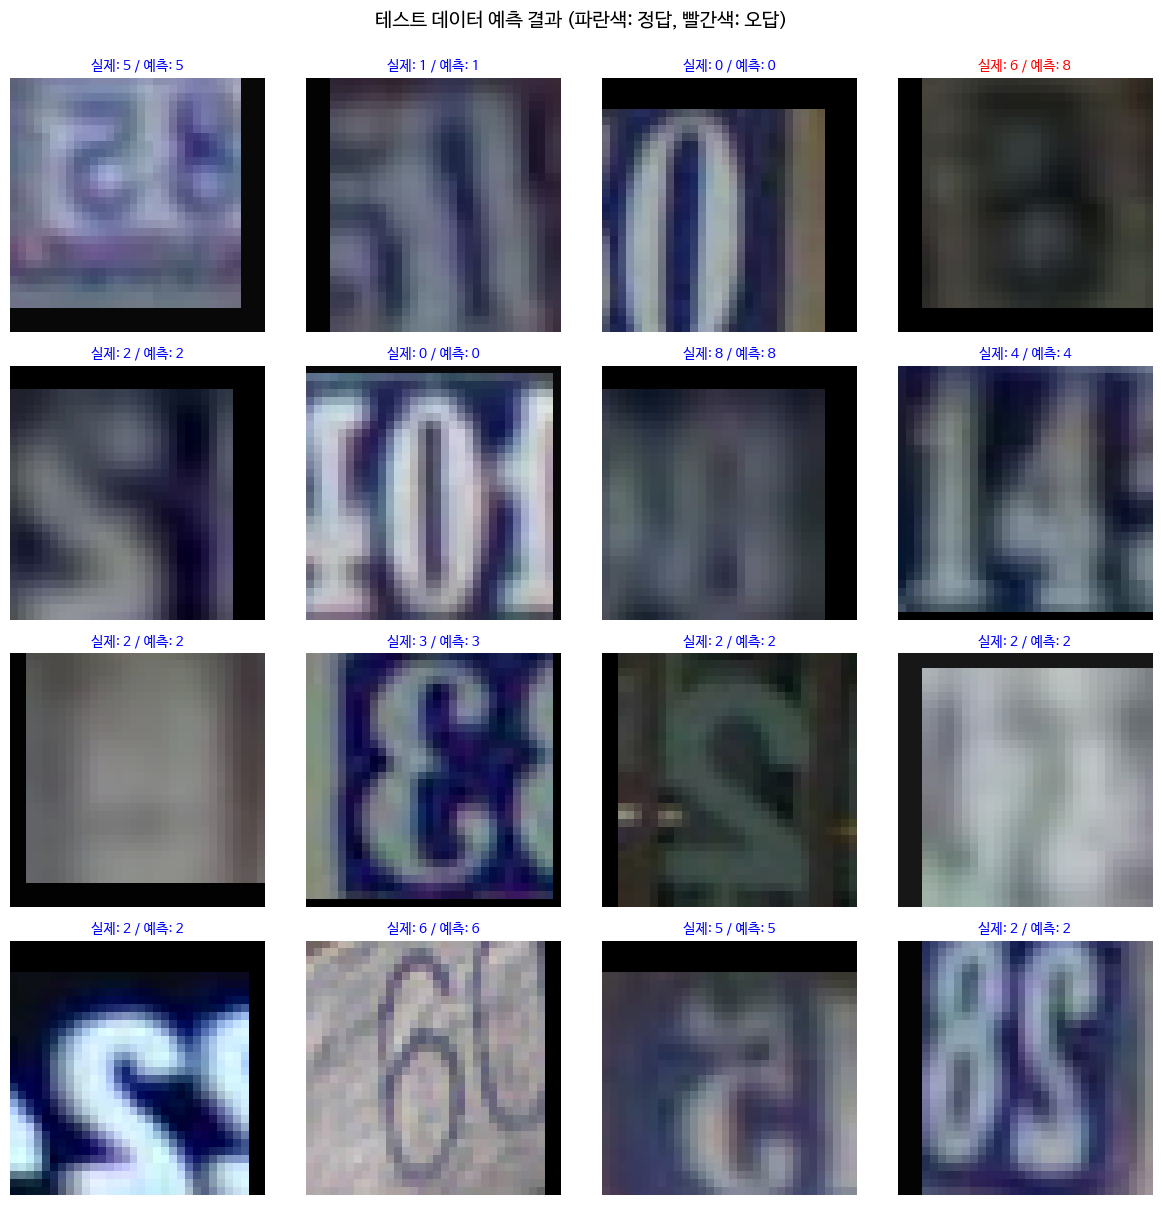


현재 배치 정확도: 85.16% (109/128)


In [85]:
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)


# CPU로 이동 및 역정규화
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()


# 16개 샘플 시각화
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)


    # 이미지 역정규화 및 차원 변환
    img = denormalize(images[i]).numpy().transpose(1, 2, 0)
    plt.imshow(img)


    # 정답과 예측 표시
    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i]]


    # 정답이면 파란색, 오답이면 빨간색
    color = 'blue' if true_label == pred_label else 'red'
    plt.title(f'실제: {true_label} / 예측: {pred_label}', color=color, fontsize=10)
    plt.axis('off')


plt.suptitle('테스트 데이터 예측 결과 (파란색: 정답, 빨간색: 오답)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


# 정확도 계산
correct = (predicted == labels).sum().item()
total = labels.size(0)
print(f'\n현재 배치 정확도: {100.*correct/total:.2f}% ({correct}/{total})')

혼동 행렬 계산 중: 100%|██████████| 204/204 [00:06<00:00, 30.03it/s]


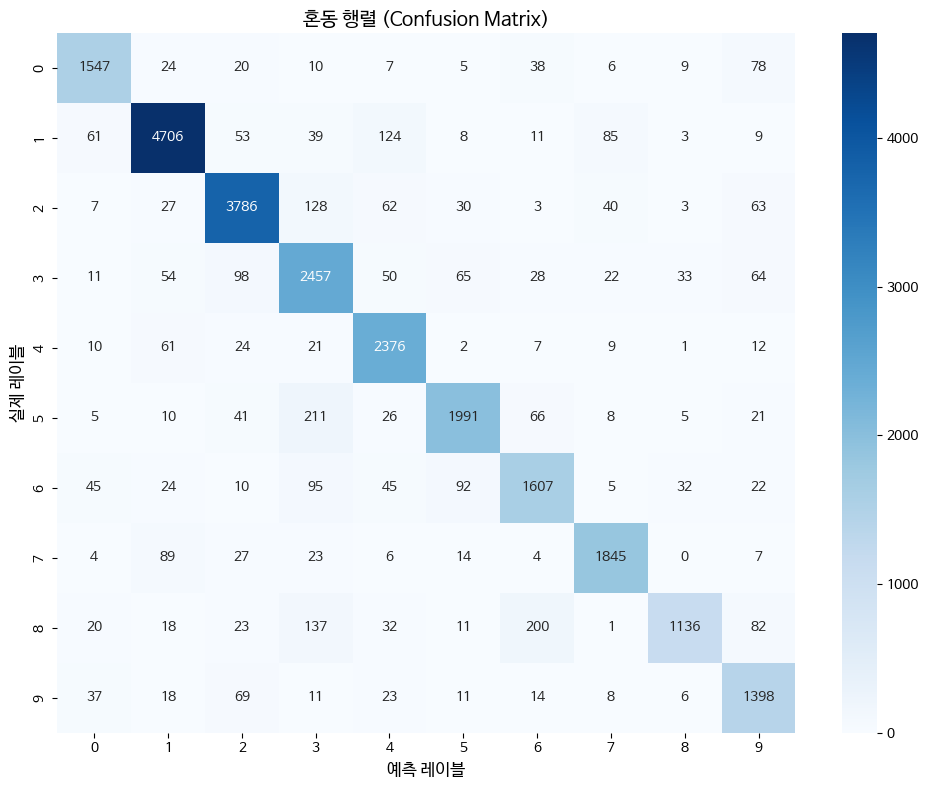


클래스별 정확도:
숫자                     정확도            샘플 수
------------------------------------------------------------
0                   88.70%            1744
1                   92.29%            5099
2                   91.25%            4149
3                   85.25%            2882
4                   94.17%            2523
5                   83.52%            2384
6                   81.28%            1977
7                   91.38%            2019
8                   68.43%            1660
9                   87.65%            1595


In [86]:
# 혼동 행렬 계산 및 시각화
from sklearn.metrics import confusion_matrix
import seaborn as sns


# 전체 테스트 데이터에 대한 예측
all_preds = []
all_labels = []


model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='혼동 행렬 계산 중'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)


        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


# 혼동 행렬 계산
cm = confusion_matrix(all_labels, all_preds)


# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('예측 레이블', fontsize=12)
plt.ylabel('실제 레이블', fontsize=12)
plt.title('혼동 행렬 (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 클래스별 정확도 계산
print('\n클래스별 정확도:')
print('='*60)
print(f'{"숫자":<10} {"정확도":>15} {"샘플 수":>15}')
print('-'*60)


for i in range(10):
    # 해당 클래스의 정확도 계산
    class_correct = cm[i, i]  # 대각선 원소 (정답)
    class_total = cm[i].sum()  # 해당 행의 합 (전체)
    class_acc = 100.0 * class_correct / class_total if class_total > 0 else 0
    print(f'{class_names[i]:<10} {class_acc:>14.2f}% {class_total:>15}')


print('='*60)